In [1]:
import numpy as np
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from bitarray import bitarray

1. Реализовать фильтр Блума (класс).
    - Выбор реализации хеш-функции зависит от вашего варианта (таблица 1).
    - Значение хеш-функции ограничить до $2^{30}$. 
    - Учесть, чтобы была возможность (т. е. опционально) при создании экземпляра значение 𝑘 и 𝑚 автоматически высчитывать в зависимости от передаваемых необязательных параметров ($\epsilon$,n) в экземпляр по формулам 2 и 3.
2. Реализовать фильтр Блума со счетом с использованием реализации из 1-го пункта.
3. Написать юнит-тесты и оценить процент ложноположительных срабатываний конкретных реализаций (фильтр Блума со счетом) и сравнить с теоретическим значением (формула 1). 
    - 𝑛 и 𝜀 выбрать в зависимости от первой буквы фамилии (таблица 2), 𝑘𝑘 и 𝑚𝑚 рассчитать по формулам 2 и 3 соответственно. 
    - Наполненность множества на 25%, 50%, 75% и 95% от числа 𝑛. 
    - При оценке необходимо проверить данными, которых нет, в количестве 100% от наполненности множества. 
    - (Т. е. если n = 15 000, множество наполнилось на 25%, и было добавлено 3 750 данных. 
    - Тогда, необходимое количество данных, которые не были добавлены – 3 750).
4. Оценить зависимость между параметрами структуры и процентом ложноположительных срабатываний (графики и таблица).
5. При реализации учесть возможность пересечения и объединения фильтров Блума через перегрузку операторов «+» (dunder add) и «–» (dunder sub), если используется Python/С++/С#, или создание публичных методов, реализующих данный функционал.
6. Произвести тестирование (юнит-тесты) операций пересечение и объединения полученных структур из 4 пункта (операции объединения и пересечения должны быть между структурами с одинаковыми параметрами и хеш-функциями). 
    - Проверить наличие и отсутствие элементов, которые должны быть в полученном множестве, и элементов, которые не должны быть, соответственно. 

In [2]:
class BloomFilter:
    def __init__(self, m:int = 0, k:int = 0, eps:float = 0, n:int = 0):
        if eps != 0 and n != 0:
            # Считаем оптимальное m
            self.m = int(np.round(- (n * np.log(eps)) / (np.log(2))**2))
            # Используем вычисленное self.m для расчета k
            self.k = int(np.round((self.m / n) * np.log(2)))
        else:
            self.m = m
            self.k = k
        self._bit_array = bitarray(self.m)
        self._bit_array.setall(0)
    
    def _blake2b_30bit(self, item, salt=b''):
        data = str(item).encode() + salt
        h = hashlib.blake2b(data, digest_size=64)
        hash_int = int.from_bytes(h.digest()[:8], byteorder='big')
        return hash_int % (1 << 30)
    
    def _get_positions_double(self, item):
        h1 = self._blake2b_30bit(item, b'1')
        h2 = self._blake2b_30bit(item, b'2')
        positions = []
        for i in range(self.k):
            combined = (h1 + i * h2) % (1 << 30)   # сначала ограничиваем 2^30
            positions.append(combined % self.m)    # затем индекс в битовом массиве
        return positions

    def add(self, item):
        pos = self._get_positions_double(item)
        for i in pos:
            self._bit_array[i] = 1

    def __add__(self, other):
        if not isinstance(other, BloomFilter):
            raise TypeError("Можно объединять только с другим BloomFilter")
        if self.m != other.m or self.k != other.k:
            raise ValueError("Фильтры должны иметь одинаковые параметры m и k")
        
        result = BloomFilter(m=self.m, k=self.k)
        result._bit_array = self._bit_array | other._bit_array
        return result

    def __sub__(self, other):
        if not isinstance(other, BloomFilter):
            raise TypeError("Можно пересекать только с другим BloomFilter")
        if self.m != other.m or self.k != other.k:
            raise ValueError("Фильтры должны иметь одинаковые параметры m и k")
        
        result = BloomFilter(m=self.m, k=self.k)
        result._bit_array = self._bit_array & other._bit_array
        return result


    def __contains__(self, item):
        pos = self._get_positions_double(item)
        for i in pos:
            if self._bit_array[i] == 0:
                return False
        return True

In [3]:
class BloomFilter_Counted:
    def __init__(self, m:int = 0, k:int = 0, eps:float = 0, n:int = 0):
        if eps != 0 and n != 0:
            # Считаем оптимальное m
            self.m = int(np.round(- (n * np.log(eps)) / (np.log(2))**2))
            # Используем вычисленное self.m для расчета k
            self.k = int(np.round((self.m / n) * np.log(2)))
        else:
            self.m = m
            self.k = k
        self._bit_array = [0] * self.m
    
    def _blake2b_30bit(self, item, salt=b''):
        data = str(item).encode() + salt
        h = hashlib.blake2b(data, digest_size=64)
        hash_int = int.from_bytes(h.digest()[:8], byteorder='big')
        return hash_int % (1 << 30)
    
    def _get_positions_double(self, item):
        h1 = self._blake2b_30bit(item, b'1')
        h2 = self._blake2b_30bit(item, b'2')
        positions = []
        for i in range(self.k):
            combined = (h1 + i * h2) % (1 << 30)   # сначала ограничиваем 2^30
            positions.append(combined % self.m)    # затем индекс в битовом массиве
        return positions

    def add(self, item):
        pos = self._get_positions_double(item)
        for i in pos:
            self._bit_array[i] += 1

    def delete(self, item):
        if item in self:
            pos = self._get_positions_double(item)
            for i in pos:
                if self._bit_array[i] > 0:
                    self._bit_array[i] -= 1

    def __add__(self, other):
        if not isinstance(other, BloomFilter_Counted):
            raise TypeError("Можно объединять только с другим BloomFilter_Counted")
        if self.m != other.m or self.k != other.k:
            raise ValueError("Фильтры должны иметь одинаковые параметры m и k")
        
        result = BloomFilter_Counted(m=self.m, k=self.k)
        result._bit_array = [a + b for a, b in zip(self._bit_array, other._bit_array)]
        return result

    def __sub__(self, other):
        if not isinstance(other, BloomFilter_Counted):
            raise TypeError("Можно пересекать только с другим BloomFilter_Counted")
        if self.m != other.m or self.k != other.k:
            raise ValueError("Фильтры должны иметь одинаковые параметры m и k")
        
        result = BloomFilter_Counted(m=self.m, k=self.k)
        result._bit_array = [min(a, b) for a, b in zip(self._bit_array, other._bit_array)]
        return result

    def __contains__(self, item):
        pos = self._get_positions_double(item)
        for i in pos:
            if self._bit_array[i] == 0:
                return False
        return True

In [4]:
def plot_bloom_analysis(n, eps, filter):
    fill_rates = [0.25, 0.50, 0.75, 0.95]
    actual_fprs = []
    theoretical_fprs = []
    for rate in fill_rates:
        bf = filter(n=n, eps=eps)
        num_items = int(n * rate)
        
        # 1. Наполняем фильтр уникальными данными
        for i in range(num_items):
            bf.add(f"data_{i}")
            
        # 2. Проверяем данные, которых точно нет (100% от наполнившихся)
        false_positives = 0
        for i in range(num_items, 2 * num_items):
            if f"data_{i}" in bf:
                false_positives += 1
        
        # 3. Считаем фактическую ошибку
        actual_fpr = false_positives / num_items
        actual_fprs.append(actual_fpr)
        
        # 4. Считаем теоретическую ошибку (формула 1)
        # k и m берутся из созданного экземпляра
        p_theory = (1 - np.exp(-bf.k * num_items / bf.m))**bf.k
        theoretical_fprs.append(p_theory)
    plt.figure(figsize=(10, 6))
    plt.plot(fill_rates, actual_fprs, 'o-', label='Фактический FPR', color='blue')
    plt.plot(fill_rates, theoretical_fprs, 's--', label='Теоретический FPR', color='red')

    plt.title(f'Зависимость FPR от наполненности (n={n}, eps={eps}) для {str(type(bf))}')
    plt.xlabel('Наполненность (доля от n)')
    plt.ylabel('Вероятность ложного срабатывания (FPR)')
    plt.xticks(fill_rates)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

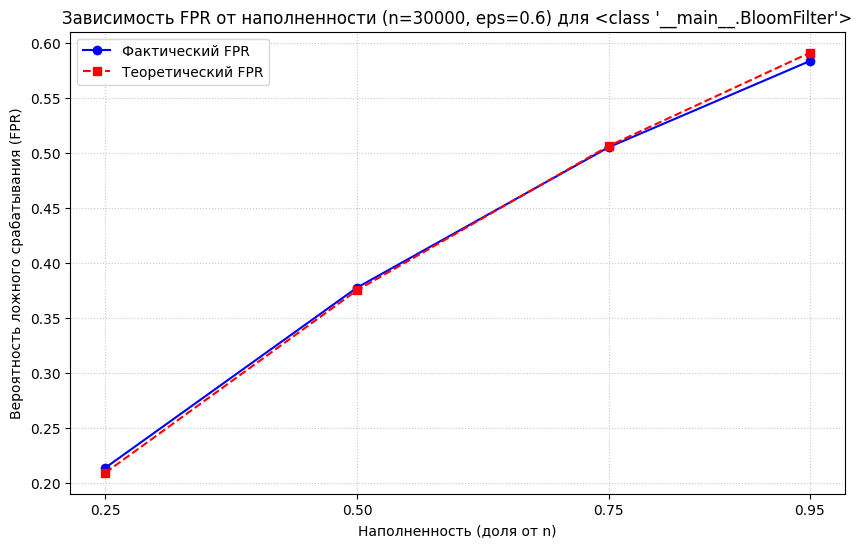

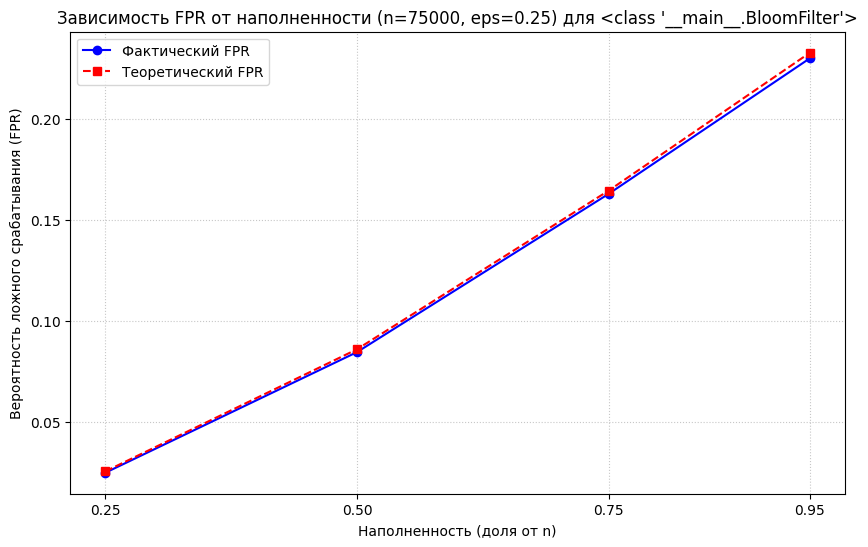

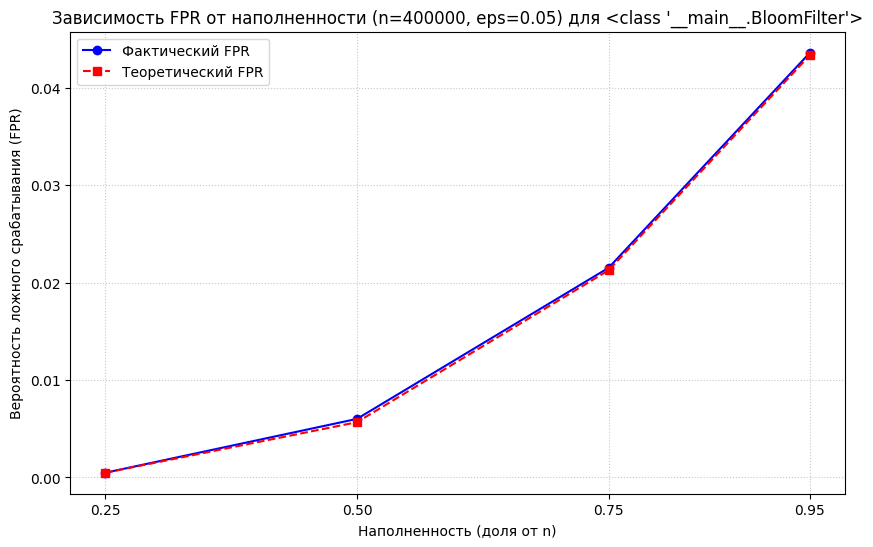

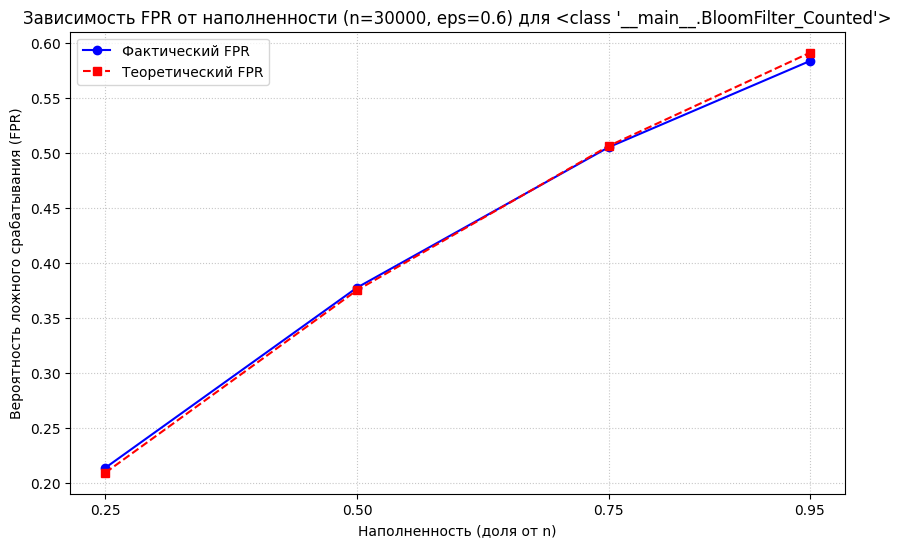

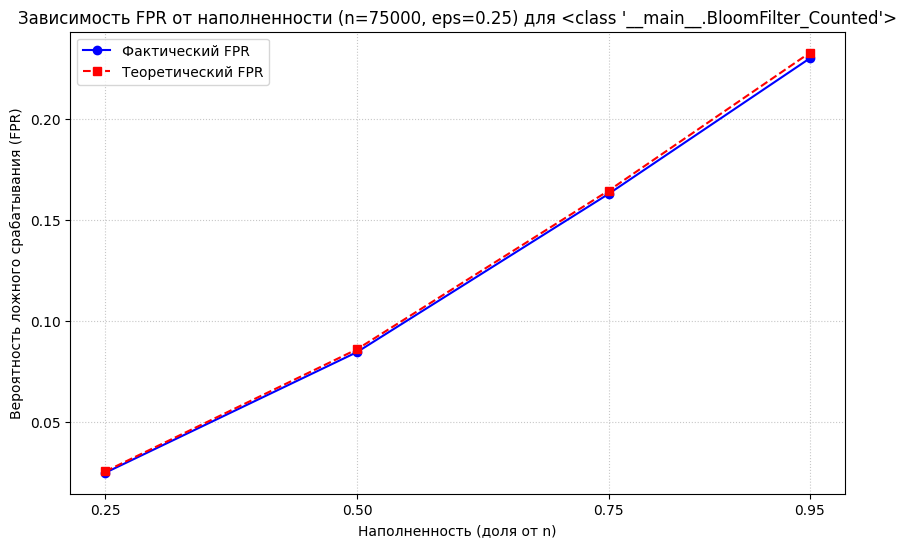

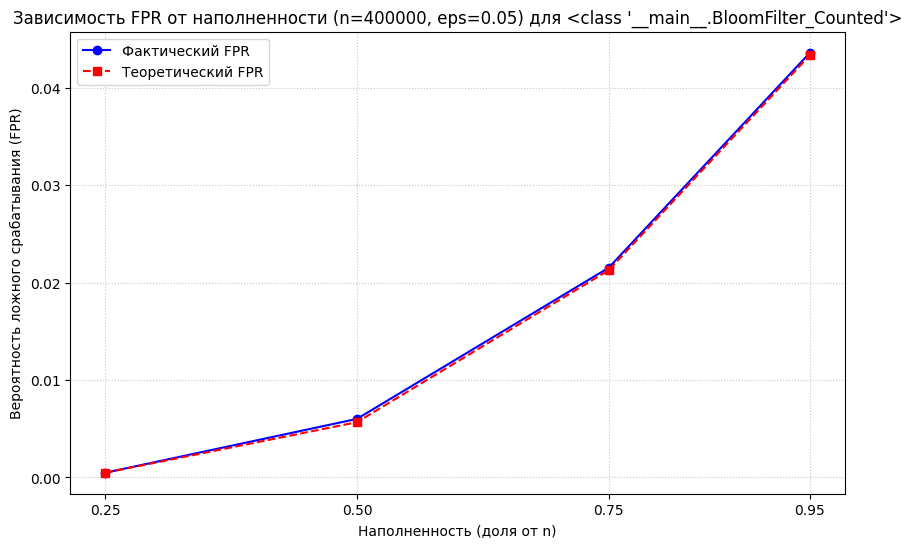

In [5]:
tests = [
    [30_000, 0.6],
    [75_000, 0.25],
    [400_000, 0.05]
]
for i in tests:
    plot_bloom_analysis(i[0], i[1], BloomFilter)
for i in tests:
    plot_bloom_analysis(i[0], i[1], BloomFilter_Counted)

In [6]:

bf1 = BloomFilter(n=1000, eps=0.05)
bf2 = BloomFilter(n=1000, eps=0.05)

bf1.add("apple")
bf2.add("orange")

bf_union = bf1 + bf2
print("apple" in bf_union)  # True
print("orange" in bf_union) # True

bf_inter = bf1 - bf2 
print("apple" in bf_inter)  # False (так как нет в bf2)

True
True
False
